# **Dog Breed Classification Using CNN**

Team:

Sree Nandha,
Saroj Kothakota

In [1]:
!pip install pyspark

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyspark: filename=pyspark-3.5.1-py2.py3-none-any.whl size=317488491 sha256=e32cd0870af6cf27ebbfb3412554a5f2dd31f532320c7f4b94302c6885f7503d
  Stored in directory: /root/.cache/pip/wheels/80/1d/60/2c256ed38dddce2fdd93be545214a63e02fbd8d74fb0b7f3a6
Successfully built pyspark


In [69]:
import os
import requests
import tarfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import confusion_matrix
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from pyspark.sql import SparkSession
from pyspark.sql.functions import regexp_extract, col, udf
from pyspark.sql.types import StringType, IntegerType, ArrayType
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.linalg import Vectors
from PIL import Image
import time
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()

# **Data Collection**

In [3]:
# Step 1: Download the dataset
dataset_url = "http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar"

In [4]:
# Download the dataset using requests
response = requests.get(dataset_url)
with open('images.tar', 'wb') as f:
    f.write(response.content)

In [5]:
# Step 2: Extract the tar file
tar_path = 'images.tar'
extract_dir = 'images'


In [6]:
# Extract the tar file
with tarfile.open(tar_path, 'r') as tar_ref:
    tar_ref.extractall(extract_dir)

In [7]:
# Step 3: Verify extraction
print(f"Contents of {extract_dir}:")
extracted_contents = os.listdir(extract_dir)
print(extracted_contents)


Contents of images:
['Images']


In [8]:
# Check if 'Images' directory exists
if 'Images' not in extracted_contents:
    print("'Images' directory not found. Listing all contents of extracted directory:")
    for root, dirs, files in os.walk(extract_dir):
        print(root, dirs, files)
else:
    extracted_dir = os.path.join(extract_dir, 'Images')

In [9]:
# Verify extracted directory
if not os.path.exists(extracted_dir):
    raise FileNotFoundError(f"Directory {extracted_dir} does not exist.")

In [10]:
# Check subdirectories (breeds)
for subdir in os.listdir(extracted_dir):
    subdir_path = os.path.join(extracted_dir, subdir)
    if os.path.isdir(subdir_path):
        print(f"Contents of {subdir_path}: {os.listdir(subdir_path)[:5]}")

Contents of images/Images/n02091635-otterhound: ['n02091635_1372.jpg', 'n02091635_470.jpg', 'n02091635_452.jpg', 'n02091635_938.jpg', 'n02091635_1333.jpg']
Contents of images/Images/n02107574-Greater_Swiss_Mountain_dog: ['n02107574_1055.jpg', 'n02107574_1952.jpg', 'n02107574_1597.jpg', 'n02107574_2386.jpg', 'n02107574_1077.jpg']
Contents of images/Images/n02104365-schipperke: ['n02104365_9131.jpg', 'n02104365_5551.jpg', 'n02104365_10399.jpg', 'n02104365_9041.jpg', 'n02104365_2940.jpg']
Contents of images/Images/n02090721-Irish_wolfhound: ['n02090721_4188.jpg', 'n02090721_3034.jpg', 'n02090721_296.jpg', 'n02090721_309.jpg', 'n02090721_6007.jpg']
Contents of images/Images/n02109961-Eskimo_dog: ['n02109961_16491.jpg', 'n02109961_546.jpg', 'n02109961_131.jpg', 'n02109961_1767.jpg', 'n02109961_2599.jpg']
Contents of images/Images/n02116738-African_hunting_dog: ['n02116738_3365.jpg', 'n02116738_1948.jpg', 'n02116738_5683.jpg', 'n02116738_7590.jpg', 'n02116738_7008.jpg']
Contents of images/Im

In [11]:
# Step 5: Manually list all image file paths
all_image_paths = []
for subdir in os.listdir(extracted_dir):
    subdir_path = os.path.join(extracted_dir, subdir)
    if os.path.isdir(subdir_path):
        for file_name in os.listdir(subdir_path):
            if file_name.endswith(".jpg"):
                file_path = os.path.join(subdir_path, file_name)
                all_image_paths.append((file_path,))

In [12]:
# Verify image paths
print(f"Number of image files found: {len(all_image_paths)}")
print("Sample image paths:", all_image_paths[:5])

Number of image files found: 20580
Sample image paths: [('images/Images/n02091635-otterhound/n02091635_1372.jpg',), ('images/Images/n02091635-otterhound/n02091635_470.jpg',), ('images/Images/n02091635-otterhound/n02091635_452.jpg',), ('images/Images/n02091635-otterhound/n02091635_938.jpg',), ('images/Images/n02091635-otterhound/n02091635_1333.jpg',)]


# **Data Exploration**

In [16]:
# Create a SparkSession
spark = SparkSession.builder \
    .appName("Spark") \
    .getOrCreate()

/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


In [17]:
# Step 6: Create a Spark DataFrame from the list of file paths
image_files = spark.createDataFrame(all_image_paths, ["file_path"])
image_files_df = pd.DataFrame(all_image_paths, columns=["file_path"])

In [65]:
image_files.show(5, truncate=False)

+-----------------------------------------------------+
|file_path                                            |
+-----------------------------------------------------+
|images/Images/n02091635-otterhound/n02091635_1372.jpg|
|images/Images/n02091635-otterhound/n02091635_470.jpg |
|images/Images/n02091635-otterhound/n02091635_452.jpg |
|images/Images/n02091635-otterhound/n02091635_938.jpg |
|images/Images/n02091635-otterhound/n02091635_1333.jpg|
+-----------------------------------------------------+
only showing top 5 rows



In [18]:
# Step 8: # Step 8: Extract breed from file path using regexp_extract to remove the numeric prefix
image_files = image_files.withColumn('breed', regexp_extract('file_path', r'\/Images\/n[0-9]+-(.*?)/', 1))
image_files_df['breed'] = image_files_df['file_path'].str.extract(r'/Images/n[0-9]+-(.*?)/')[0]

In [19]:
print("Sample extracted breed values:")
image_files.select('file_path', 'breed').show(5, truncate=False)

Sample extracted breed values:
+-----------------------------------------------------+----------+
|file_path                                            |breed     |
+-----------------------------------------------------+----------+
|images/Images/n02091635-otterhound/n02091635_1372.jpg|otterhound|
|images/Images/n02091635-otterhound/n02091635_470.jpg |otterhound|
|images/Images/n02091635-otterhound/n02091635_452.jpg |otterhound|
|images/Images/n02091635-otterhound/n02091635_938.jpg |otterhound|
|images/Images/n02091635-otterhound/n02091635_1333.jpg|otterhound|
+-----------------------------------------------------+----------+
only showing top 5 rows



In [20]:
breed_counts = image_files.groupBy("breed").count()

In [21]:
breed_counts_pd = breed_counts.toPandas()

In [22]:
print(breed_counts_pd.head())


                        breed  count
0  Greater_Swiss_Mountain_dog    168
1                    Pembroke    181
2         African_hunting_dog    169
3             Irish_wolfhound    218
4                  schipperke    154


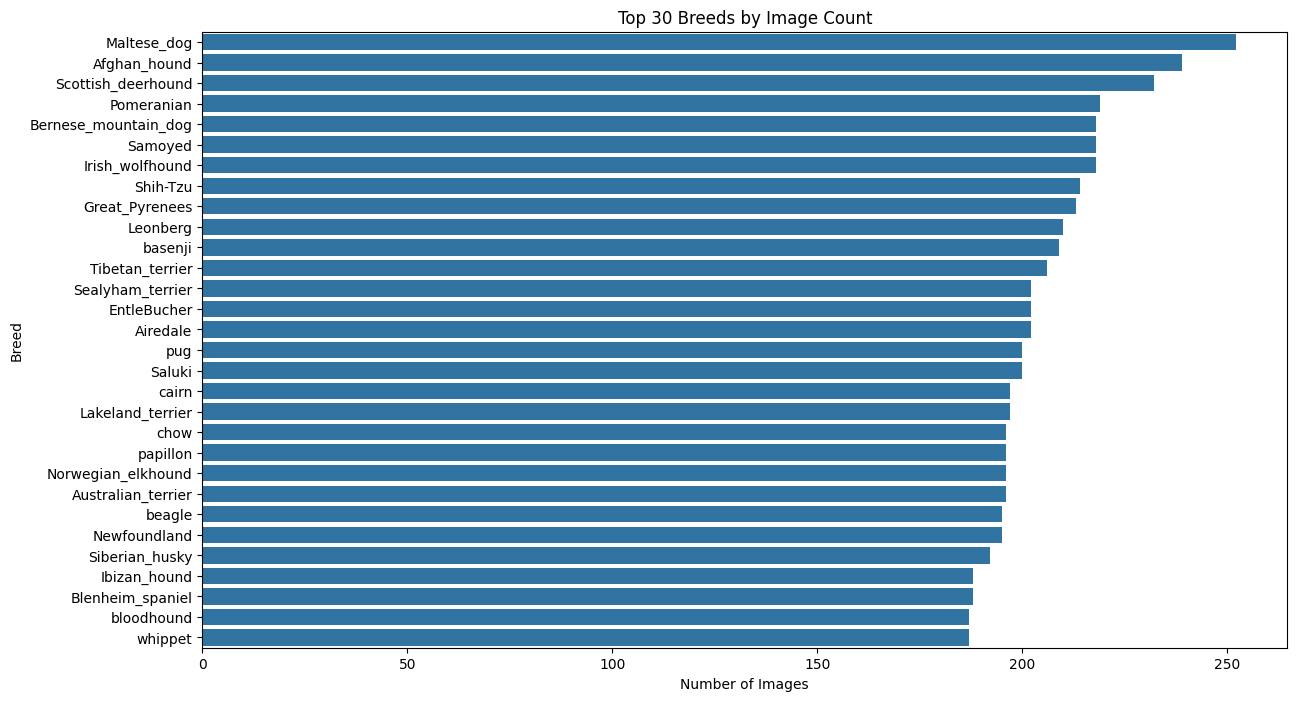

In [23]:
plt.figure(figsize=(14, 8))
sns.barplot(y='breed', x='count', data=breed_counts_pd.sort_values(by='count', ascending=False).head(30))
plt.title('Top 30 Breeds by Image Count')
plt.xlabel('Number of Images')
plt.ylabel('Breed')
plt.show()

In [24]:
image_files_df.to_csv("dogbreed.csv")

In [25]:
df1= pd.read_csv("dogbreed.csv")
df1

,Unnamed: 0,file_path,breed
0,0,images/Images/n02091635-otterhound/n02091635_1...,otterhound
1,1,images/Images/n02091635-otterhound/n02091635_4...,otterhound
2,2,images/Images/n02091635-otterhound/n02091635_4...,otterhound
3,3,images/Images/n02091635-otterhound/n02091635_9...,otterhound
4,4,images/Images/n02091635-otterhound/n02091635_1...,otterhound
...,...,...,...
20575,20575,images/Images/n02098413-Lhasa/n02098413_3007.jpg,Lhasa
20576,20576,images/Images/n02098413-Lhasa/n02098413_1718.jpg,Lhasa
20577,20577,images/Images/n02098413-Lhasa/n02098413_7546.jpg,Lhasa
20578,20578,images/Images/n02098413-Lhasa/n02098413_387.jpg,Lhasa


In [26]:
df1 = df1[['file_path', 'breed']]

/usr/lib/python3.10/subprocess.py:1796: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = _posixsubprocess.fork_exec(


In [27]:
# Convert Pandas DataFrame to Spark DataFrame
sdf = spark.createDataFrame(df1)
sdf.show()
sdf.count()

+--------------------+----------+
|           file_path|     breed|
+--------------------+----------+
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
+--------------------+----------+
only showing top 20 rows



20580

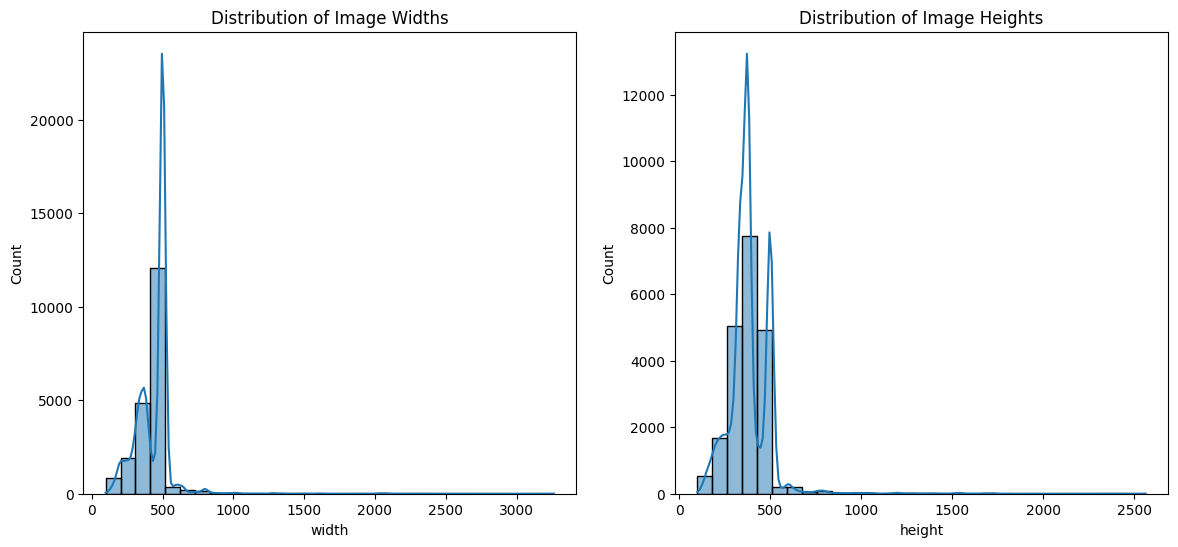

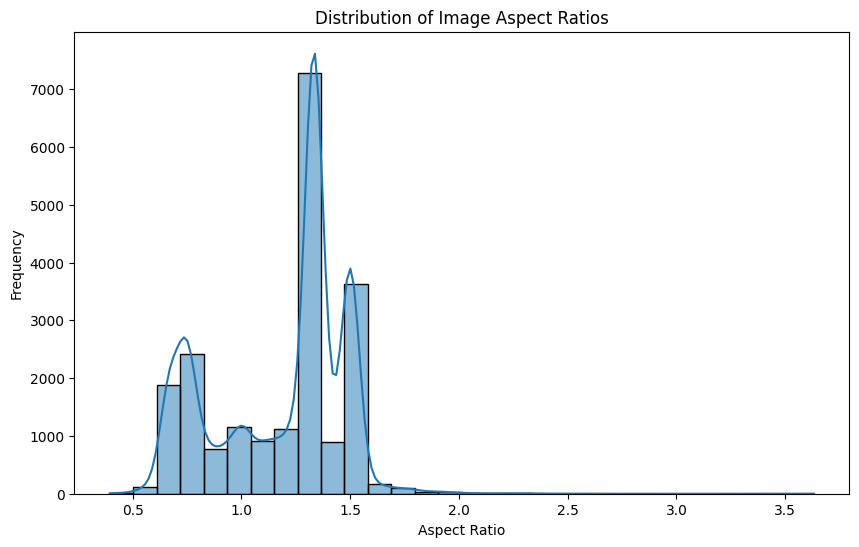

In [30]:
# Register UDFs to get image width and height
def get_image_width(image_path):
    height, width = get_image_dimensions(image_path)
    return width

def get_image_height(image_path):
    height, width = get_image_dimensions(image_path)
    return height

get_image_width_udf = udf(get_image_width, IntegerType())
get_image_height_udf = udf(get_image_height, IntegerType())

# Apply UDFs to get image dimensions
image_dimensions = image_files.withColumn('width', get_image_width_udf(col('file_path')))
image_dimensions = image_dimensions.withColumn('height', get_image_height_udf(col('file_path')))
image_dimensions = image_dimensions.withColumn('aspect_ratio', col('width') / col('height'))

# Filter out rows where the width or height is None due to errors
image_dimensions = image_dimensions.filter(col('width').isNotNull() & col('height').isNotNull())

# Convert to Pandas DataFrame
image_dims_pd = image_dimensions.toPandas()

# Plot the distribution of image widths and heights
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.histplot(image_dims_pd['width'], bins=30, kde=True)
plt.title('Distribution of Image Widths')

plt.subplot(1, 2, 2)
sns.histplot(image_dims_pd['height'], bins=30, kde=True)
plt.title('Distribution of Image Heights')

plt.show()

# Plot aspect ratio distribution
plt.figure(figsize=(10, 6))
sns.histplot(image_dims_pd['aspect_ratio'], bins=30, kde=True)
plt.title('Distribution of Image Aspect Ratios')
plt.xlabel('Aspect Ratio')
plt.ylabel('Frequency')
plt.show()

**Observations**

Most images in the dataset are about 360 pixels wide and 236 pixels tall. There are some variations in sizes, likely due to different aspect ratios or resolutions. Overall, the images tend to be on the smaller side.

The Aspect ratio graph shows the distribution of aspect ratios among the images in the dataset. There is a prominent peak around an aspect ratio of 0.655, indicating that most images share this specific aspect ratio. The distribution also has smaller peaks at other aspect ratio values, suggesting there are some variations in the aspect ratios present.

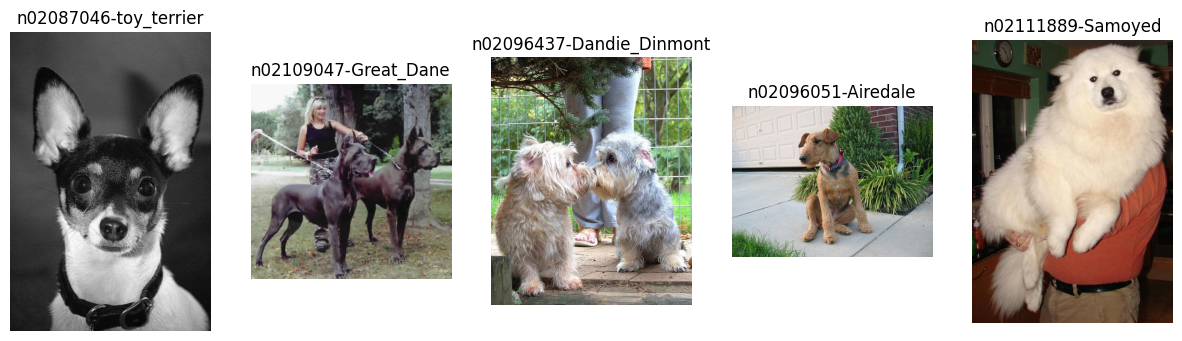

In [31]:
# Function to display sample images
def display_sample_images(df, n=5):
    sample_paths = df.sample(n)['file_path'].tolist()
    plt.figure(figsize=(15, 15))
    for i, img_path in enumerate(sample_paths):
        img = Image.open(img_path)
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis('off')
        plt.title(img_path.split('/')[-2])
    plt.show()

# Display sample images
display_sample_images(image_dims_pd)

In [32]:
sdf.show()

+--------------------+----------+
|           file_path|     breed|
+--------------------+----------+
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
|images/Images/n02...|otterhound|
+--------------------+----------+
only showing top 20 rows



# **Data Preprocessing**

In [29]:
# Define a function to get image dimensions
def get_image_dimensions(image_path):
    try:
        image = cv2.imread(image_path)
        if image is not None:
            height, width, _ = image.shape
            return height, width
        else:
            return None, None
    except Exception as e:
        print(f"Error processing image: {e}")
        return None, None

In [33]:
# Define a UDF to apply the function to each row
get_dimensions_udf = udf(lambda image_path: get_image_dimensions(file_path), ArrayType(IntegerType()))  # Use ArrayType

# Apply the UDF to the Image column to get height and width
sdf_with_dimensions = sdf.withColumn("Dimensions", get_dimensions_udf(sdf["breed"]))

# Extract height and width into separate columns
sdf_with_dimensions = sdf_with_dimensions.withColumn("Height", sdf_with_dimensions["Dimensions"].getItem(0)) \
                                         .withColumn("Width", sdf_with_dimensions["Dimensions"].getItem(1)) \
                                         .drop("Dimensions")
sdf_with_dimensions.show()

+--------------------+----------+------+-----+
|           file_path|     breed|Height|Width|
+--------------------+----------+------+-----+
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Images/n02...|otterhound|   236|  360|
|images/Image

In [34]:
target_shape=(128, 128)
aspect_ratio_range=(0.6, 1.34)
# Filter images based on dimensions
sdf_filtered = sdf_with_dimensions.filter((col('Height') >= target_shape[0]) & (col('Width') >= target_shape[1]))

# Calculate aspect ratio and filter images based on aspect ratio range
sdf_filtered = sdf_filtered.withColumn('HeightWidthRatio', col('Height') / col('Width'))
sdf_filtered = sdf_filtered.filter((col('HeightWidthRatio') >= aspect_ratio_range[0]) & (col('HeightWidthRatio') <= aspect_ratio_range[1]))

# Drop the temporary column
#sdf_filtered = sdf_filtered.drop('HeightWidthRatio')

# Show the filtered DataFrame
sdf_filtered.show()
sdf_filtered_pd = sdf_filtered.toPandas()

+--------------------+----------+------+-----+------------------+
|           file_path|     breed|Height|Width|  HeightWidthRatio|
+--------------------+----------+------+-----+------------------+
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Images/n02...|otterhound|   236|  360|0.6555555555555556|
|images/Im

In [35]:
sdf_filtered_pd

,file_path,breed,Height,Width,HeightWidthRatio
0,images/Images/n02091635-otterhound/n02091635_1...,otterhound,236,360,0.655556
1,images/Images/n02091635-otterhound/n02091635_4...,otterhound,236,360,0.655556
2,images/Images/n02091635-otterhound/n02091635_4...,otterhound,236,360,0.655556
3,images/Images/n02091635-otterhound/n02091635_9...,otterhound,236,360,0.655556
4,images/Images/n02091635-otterhound/n02091635_1...,otterhound,236,360,0.655556
...,...,...,...,...,...
20575,images/Images/n02098413-Lhasa/n02098413_3007.jpg,Lhasa,236,360,0.655556
20576,images/Images/n02098413-Lhasa/n02098413_1718.jpg,Lhasa,236,360,0.655556
20577,images/Images/n02098413-Lhasa/n02098413_7546.jpg,Lhasa,236,360,0.655556
20578,images/Images/n02098413-Lhasa/n02098413_387.jpg,Lhasa,236,360,0.655556


In [36]:
# grey scale conversion
from PIL import Image, UnidentifiedImageError
def grey_image(file_path,IMAGE_SHAPE=(128, 128)):
        img = Image.open(file_path)
        img = img.resize(IMAGE_SHAPE, Image.LANCZOS).convert(mode="L")
        # img = img.resize(IMAGE_SHAPE, Image.LANCZOS).convert(mode="RGB")
        return np.array(img)


# Resizing and converting the entire dataset to grayscale
sdf_filtered_pd['data'] = sdf_filtered_pd.progress_apply(lambda row: grey_image(row.file_path), axis=1)


100%|██████████| 20580/20580 [01:26<00:00, 238.56it/s]


In [37]:
sdf_filtered_pd

,file_path,breed,Height,Width,HeightWidthRatio,data
0,images/Images/n02091635-otterhound/n02091635_1...,otterhound,236,360,0.655556,"[[0, 2, 0, 71, 182, 176, 179, 179, 180, 181, 1..."
1,images/Images/n02091635-otterhound/n02091635_4...,otterhound,236,360,0.655556,"[[35, 36, 36, 35, 35, 35, 38, 40, 44, 45, 45, ..."
2,images/Images/n02091635-otterhound/n02091635_4...,otterhound,236,360,0.655556,"[[163, 152, 160, 152, 151, 152, 156, 155, 135,..."
3,images/Images/n02091635-otterhound/n02091635_9...,otterhound,236,360,0.655556,"[[168, 189, 113, 122, 120, 121, 121, 120, 120,..."
4,images/Images/n02091635-otterhound/n02091635_1...,otterhound,236,360,0.655556,"[[253, 250, 246, 244, 246, 243, 248, 247, 241,..."
...,...,...,...,...,...,...
20575,images/Images/n02098413-Lhasa/n02098413_3007.jpg,Lhasa,236,360,0.655556,"[[24, 27, 24, 28, 25, 25, 20, 14, 32, 47, 44, ..."
20576,images/Images/n02098413-Lhasa/n02098413_1718.jpg,Lhasa,236,360,0.655556,"[[75, 74, 76, 71, 74, 92, 92, 99, 101, 104, 10..."
20577,images/Images/n02098413-Lhasa/n02098413_7546.jpg,Lhasa,236,360,0.655556,"[[21, 23, 18, 9, 9, 10, 14, 17, 7, 11, 6, 6, 9..."
20578,images/Images/n02098413-Lhasa/n02098413_387.jpg,Lhasa,236,360,0.655556,"[[48, 49, 49, 42, 35, 42, 53, 53, 52, 53, 48, ..."


In [38]:
sdf_filtered_pd['breed'].value_counts()

breed
Maltese_dog               252
Afghan_hound              239
Scottish_deerhound        232
Pomeranian                219
Irish_wolfhound           218
                         ... 
Welsh_springer_spaniel    150
dhole                     150
Irish_water_spaniel       150
Pekinese                  149
redbone                   148
Name: count, Length: 120, dtype: int64

# **Model Creation**

In [39]:
sns.set()
sns.set_style("whitegrid")

# Convert resized_image column to a format compatible with TensorFlow
assembler = VectorAssembler(inputCols=["height", "width"], outputCol="Data")


In [40]:
# Creating the model
IMAGE_SHAPE=(128, 128)
input_shape = (*IMAGE_SHAPE, 1)
num_classes = len(sdf_filtered_pd['breed'].unique())

model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Conv2D(16, kernel_size=(5, 5), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(32, kernel_size=(5, 5), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(64, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(128, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Conv2D(256, kernel_size=(3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D(pool_size=(2, 2)),
        layers.Dropout(0.25),

        layers.Dense(128, activation="relu"),
        layers.Flatten(),
        layers.Dropout(0.25),
        layers.Dense(num_classes, activation="softmax")
    ]
)

In [41]:
# Separating training and testing data
X_train, X_test, y_train, y_test = train_test_split(
                                    sdf_filtered_pd['data'],
                                    sdf_filtered_pd['breed'],
                                    stratify=sdf_filtered_pd['breed'], test_size=0.3, random_state=42)


# Data preprocessing
X_train = np.concatenate(X_train.values).reshape(-1, *input_shape)
X_test = np.concatenate(X_test.values).reshape(-1, *input_shape)

X_train = X_train.astype(np.float32) / 255
X_test = X_test.astype(np.float32) / 255


# Encoding labels
encoder = {v: k for k, v in enumerate(sdf_filtered_pd['breed'].unique())}

y_train = y_train.map(encoder)
y_test = y_test.map(encoder)

y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

# **Training model**

In [66]:
# Hyperparameters
batch_size = 128
epochs = 5

model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])

# Separate the validation data
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=True)

# Model training
history = model.fit(X_train1,
                    y_train1,
                    batch_size=batch_size,
                    epochs=epochs,
                    validation_data=(X_val, y_val),
                    shuffle=True)


# Evaluating the model
score = model.evaluate(X_val, y_val, verbose=0)
print("Trained the model with 14406 images:")
print("Test loss:", score[0])
print("Test accuracy:", score[1])

Epoch 1/5
91/91 [==============================] - 5s 33ms/step - loss: 0.7235 - accuracy: 0.7853 - val_loss: 0.5498 - val_accuracy: 0.8529
Epoch 2/5
91/91 [==============================] - 3s 31ms/step - loss: 0.6819 - accuracy: 0.7949 - val_loss: 0.5551 - val_accuracy: 0.8477
Epoch 3/5
91/91 [==============================] - 3s 31ms/step - loss: 0.6940 - accuracy: 0.7942 - val_loss: 0.6360 - val_accuracy: 0.8310
Epoch 4/5
91/91 [==============================] - 3s 31ms/step - loss: 0.6619 - accuracy: 0.7999 - val_loss: 0.7769 - val_accuracy: 0.7929
Epoch 5/5
91/91 [==============================] - 3s 32ms/step - loss: 0.5938 - accuracy: 0.8202 - val_loss: 0.4600 - val_accuracy: 0.8834
Trained the model with 14406 images:
Test loss: 0.6461605429649353
Test accuracy: 0.8258153796195984


# **Model Evaluation**

91/91 [==============================] - 0s 3ms/step
The predictions on a range of 10:
Correct predictions: 8
Wrong predictions: 2


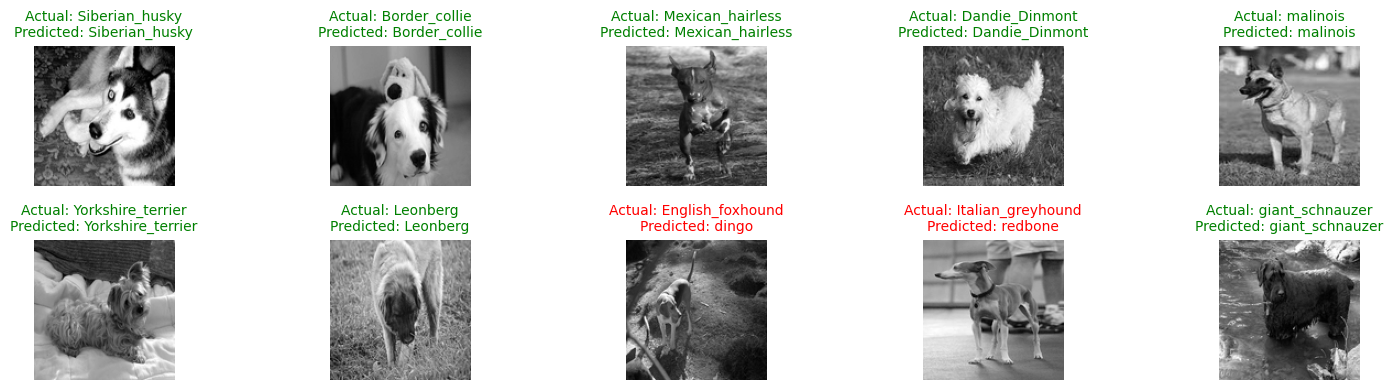

In [67]:
# Make predictions on the test data
predictions = model.predict(X_val)

# Decode the predicted labels back to breed names
predicted_labels = np.argmax(predictions, axis=1)
predicted_breeds = [list(encoder.keys())[list(encoder.values()).index(label)] for label in predicted_labels]

# Decode the actual labels back to breed names
actual_labels = np.argmax(y_val, axis=1)
actual_breeds = [list(encoder.keys())[list(encoder.values()).index(label)] for label in actual_labels]

# Display a sample of images from the test data with their predicted and actual breed names
correct_predictions = 0
wrong_predictions = 0

# Display a sample of 5 images from the test data with their predicted and actual breed names
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_val[i].reshape(IMAGE_SHAPE), cmap='gray')

    # Check if the prediction is correct
    if predicted_breeds[i] == actual_breeds[i]:
        font_color = 'green'  # Correct prediction, set font color to green
        correct_predictions += 1
    else:
        font_color = 'red'  # Incorrect prediction, set font color to red
        wrong_predictions += 1

    plt.title(f'Actual: {actual_breeds[i]}\nPredicted: {predicted_breeds[i]}', fontsize=10, color=font_color)
    plt.axis('off')

print(f'The predictions on a range of 10:')
# Print the number of correct and wrong predictions
print(f'Correct predictions: {correct_predictions}')
print(f'Wrong predictions: {wrong_predictions}')
plt.tight_layout()
plt.show()


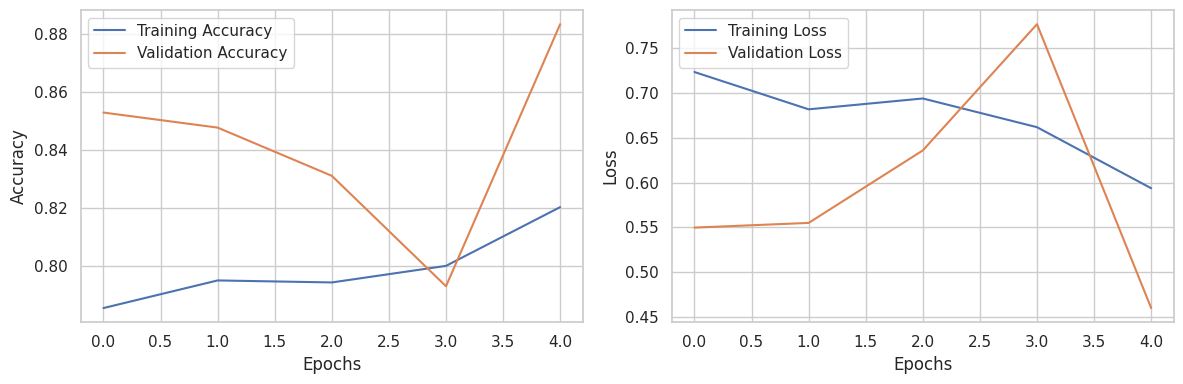

In [68]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()